# Лабораторная: Bilateral filtering на GPU

В этом ноутбуке реализован **9-точечный bilateral-фильтр** для полутонового BMP-изображения:
- последовательная версия на CPU;
- параллельная версия на GPU (CUDA через Numba);
- замер времени для CPU и GPU;
- сохранение результатов в BMP.

Формулы и требования взяты из `bilateral.pdf`.

In [9]:
import math
import time
from pathlib import Path

import numpy as np
from PIL import Image

try:
    from numba import cuda
    CUDA_AVAILABLE = cuda.is_available()
except Exception:
    cuda = None
    CUDA_AVAILABLE = False
print(f"CUDA доступна: {CUDA_AVAILABLE}")

CUDA доступна: True


In [10]:
# Входные данные (по заданию: BMP + sigma-параметры)
INPUT_BMP = Path("input1.bmp")
SIGMA_D = 1.5
SIGMA_R = 25.0

# Выходные файлы
CPU_OUT = Path("output_cpu1.bmp")
GPU_OUT = Path("output_gpu1.bmp")

# Если input.bmp не найден, пытаемся автоматически взять первый подходящий BMP
if not INPUT_BMP.exists():
    bmp_candidates = sorted(Path(".").glob("*.bmp"))
    bmp_candidates = [p for p in bmp_candidates if p.name.lower() not in {CPU_OUT.name.lower(), GPU_OUT.name.lower()}]

    if len(bmp_candidates) == 0:
        raise FileNotFoundError(
            "Не найден входной BMP. Положите файл input.bmp (или любой другой *.bmp) рядом с ноутбуком."
        )

    INPUT_BMP = bmp_candidates[0]
    print(f"input.bmp не найден, выбран файл: {INPUT_BMP}")

print("Конфигурация:")
print("  INPUT_BMP =", INPUT_BMP.resolve())
print("  SIGMA_D   =", SIGMA_D)
print("  SIGMA_R   =", SIGMA_R)

Конфигурация:
  INPUT_BMP = /content/input1.bmp
  SIGMA_D   = 1.5
  SIGMA_R   = 25.0


In [11]:
def load_grayscale_bmp(path: Path) -> np.ndarray:
    """Загружает BMP в полутоновый формат uint8 (H, W)."""
    img = Image.open(path).convert("L")
    arr = np.array(img, dtype=np.uint8)
    return arr

def save_grayscale_bmp(path: Path, arr: np.ndarray) -> None:
    """Сохраняет массив uint8 (H, W) в BMP."""
    img = Image.fromarray(arr.astype(np.uint8), mode="L")
    img.save(path, format="BMP")

def bilateral_cpu_3x3(src_u8: np.ndarray, sigma_d: float, sigma_r: float):
    """
    9-точечный bilateral-фильтр с политикой границ nearest (clamp).
    Возвращает (результат_uint8, время_сек).
    """
    h, w = src_u8.shape
    src = src_u8.astype(np.float32)
    out = np.empty_like(src, dtype=np.float32)

    # Предвычисляем пространственные веса для окна 3x3
    spatial = np.zeros((3, 3), dtype=np.float32)
    for dy in range(-1, 2):
        for dx in range(-1, 2):
            spatial[dy + 1, dx + 1] = math.exp(-((dx * dx + dy * dy) / (2.0 * sigma_d * sigma_d)))

    t0 = time.perf_counter()
    for y in range(h):
        for x in range(w):
            center = src[y, x]
            num = 0.0
            den = 0.0

            for dy in range(-1, 2):
                yy = min(max(y + dy, 0), h - 1)
                for dx in range(-1, 2):
                    xx = min(max(x + dx, 0), w - 1)
                    neigh = src[yy, xx]

                    wr = math.exp(-(((neigh - center) * (neigh - center)) / (2.0 * sigma_r * sigma_r)))
                    w_all = spatial[dy + 1, dx + 1] * wr

                    num += neigh * w_all
                    den += w_all

            out[y, x] = num / den if den > 1e-12 else center

    dt = time.perf_counter() - t0
    return np.clip(out, 0, 255).astype(np.uint8), dt


if CUDA_AVAILABLE:
    @cuda.jit
    def bilateral_gpu_kernel_3x3(src, dst, sigma_d, sigma_r, h, w):
        # В Numba cuda.grid(2) возвращает (x, y)
        x, y = cuda.grid(2)
        if y >= h or x >= w:
            return

        center = src[y, x]
        num = 0.0
        den = 0.0

        for dy in range(-1, 2):
            yy = y + dy
            if yy < 0:
                yy = 0
            elif yy >= h:
                yy = h - 1

            for dx in range(-1, 2):
                xx = x + dx
                if xx < 0:
                    xx = 0
                elif xx >= w:
                    xx = w - 1

                neigh = src[yy, xx]
                wd = math.exp(-((dx * dx + dy * dy) / (2.0 * sigma_d * sigma_d)))
                dr = neigh - center
                wr = math.exp(-((dr * dr) / (2.0 * sigma_r * sigma_r)))
                w_all = wd * wr

                num += neigh * w_all
                den += w_all

        if den > 1e-12:
            dst[y, x] = num / den
        else:
            dst[y, x] = center

def bilateral_gpu_3x3(src_u8: np.ndarray, sigma_d: float, sigma_r: float):
    """Возвращает (результат_uint8, время_сек) или (None, None), если CUDA недоступна."""
    if not CUDA_AVAILABLE:
        return None, None

    h, w = src_u8.shape
    src_f = src_u8.astype(np.float32)

    d_src = cuda.to_device(src_f)
    d_dst = cuda.device_array_like(src_f)

    threads = (16, 16)
    # blocks=(blocks_x, blocks_y): сначала ширина (x), затем высота (y)
    blocks = ((w + threads[0] - 1) // threads[0], (h + threads[1] - 1) // threads[1])

    # Прогрев JIT
    bilateral_gpu_kernel_3x3[blocks, threads](d_src, d_dst, sigma_d, sigma_r, h, w)
    cuda.synchronize()

    # Точный замер времени на GPU через CUDA events
    start_evt = cuda.event()
    end_evt = cuda.event()
    start_evt.record()
    bilateral_gpu_kernel_3x3[blocks, threads](d_src, d_dst, sigma_d, sigma_r, h, w)
    end_evt.record()
    end_evt.synchronize()

    gpu_ms = cuda.event_elapsed_time(start_evt, end_evt)
    out = d_dst.copy_to_host()
    return np.clip(out, 0, 255).astype(np.uint8), gpu_ms / 1000.0

In [12]:
# 1) Загружаем входное изображение
src = load_grayscale_bmp(INPUT_BMP)
print("Размер изображения:", src.shape)

# 2) CPU
cpu_img, cpu_time = bilateral_cpu_3x3(src, SIGMA_D, SIGMA_R)
save_grayscale_bmp(CPU_OUT, cpu_img)

# 3) GPU
gpu_img, gpu_time = bilateral_gpu_3x3(src, SIGMA_D, SIGMA_R)
if gpu_img is not None:
    save_grayscale_bmp(GPU_OUT, gpu_img)

# 4) Выводим то, что требуется в задании
print(f"Время обработки CPU: {cpu_time:.6f} c")
if gpu_time is not None:
    print(f"Время обработки GPU: {gpu_time:.6f} c")
    print(f"Ускорение GPU/CPU: {cpu_time / gpu_time:.2f}x")
else:
    print("Время обработки GPU: недоступно (CUDA не найдена)")

print("Сохранены файлы:")
print(" -", CPU_OUT.resolve())
if gpu_img is not None:
    print(" -", GPU_OUT.resolve())

Размер изображения: (359, 640)


/tmp/ipykernel_2446/1500410352.py:9: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr.astype(np.uint8), mode="L")


Время обработки CPU: 2.905733 c
Время обработки GPU: 0.003206 c
Ускорение GPU/CPU: 906.32x
Сохранены файлы:
 - /content/output_cpu1.bmp
 - /content/output_gpu1.bmp


/tmp/ipykernel_2446/1500410352.py:9: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr.astype(np.uint8), mode="L")


In [13]:
# Проверка близости CPU и GPU (если GPU есть)
if gpu_img is not None:
    max_abs_diff = np.max(np.abs(cpu_img.astype(np.int16) - gpu_img.astype(np.int16)))
    mean_abs_diff = np.mean(np.abs(cpu_img.astype(np.float32) - gpu_img.astype(np.float32)))
    print(f"Макс. абсолютное отличие CPU/GPU: {max_abs_diff}")
    print(f"Среднее абсолютное отличие CPU/GPU: {mean_abs_diff:.4f}")
else:
    print("Сравнение CPU/GPU пропущено: CUDA недоступна.")

Макс. абсолютное отличие CPU/GPU: 1
Среднее абсолютное отличие CPU/GPU: 0.0216


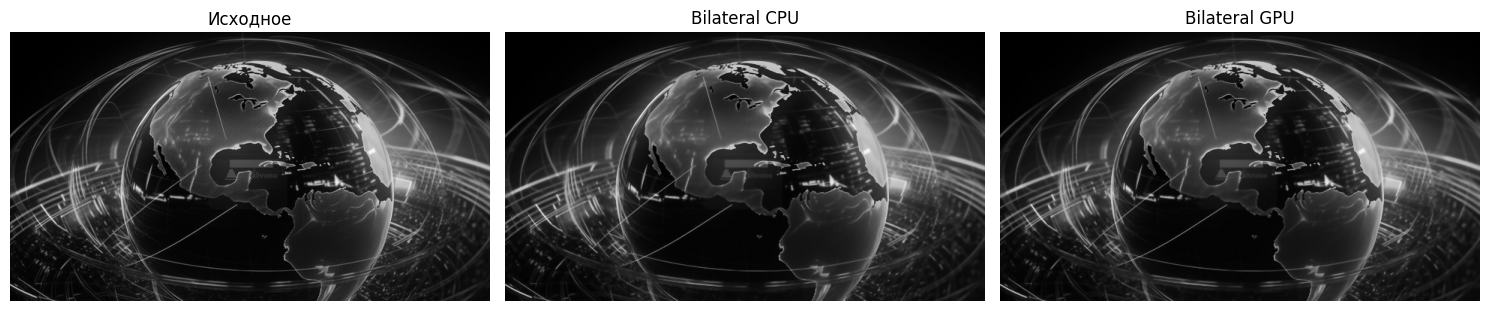

In [14]:
# Визуальное сравнение исходного изображения и результатов
try:
    import matplotlib.pyplot as plt

    cols = 3 if gpu_img is not None else 2
    plt.figure(figsize=(5 * cols, 5))

    plt.subplot(1, cols, 1)
    plt.imshow(src, cmap="gray", vmin=0, vmax=255)
    plt.title("Исходное")
    plt.axis("off")

    plt.subplot(1, cols, 2)
    plt.imshow(cpu_img, cmap="gray", vmin=0, vmax=255)
    plt.title("Bilateral CPU")
    plt.axis("off")

    if gpu_img is not None:
        plt.subplot(1, cols, 3)
        plt.imshow(gpu_img, cmap="gray", vmin=0, vmax=255)
        plt.title("Bilateral GPU")
        plt.axis("off")

    plt.tight_layout()
    plt.show()
except Exception as exc:
    print("Визуализация пропущена (matplotlib недоступен):", exc)